In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy 

In [8]:
result_dir = "result/ci_slurmctld_log.csv"

In [73]:
def extract_job_info(job_id,jobs_df,target_metrics):
    job_data = jobs_df[jobs_df['job_rec_id'] == job_id]
    info = {}
    
    for metric in target_metrics:
        metric_data = job_data[job_data['metric'] == metric]
        if not metric_data.empty:
            if metric in ['submit_job', 'job_epilog_complete', 'launch_job']:
                info[metric] = metric_data['t'].iloc[0]
            else:
                info[metric] = metric_data['value'].iloc[0]
        else:
            info[metric] = None
    return info

def calculate_metrics(result_dir):

    
    
    df = pd.read_csv(result_dir);
    jobs = df[df['job_rec_id'].notna()].copy()
    jobs['job_rec_id'] = jobs['job_rec_id'].astype(int)
    total_jobs = jobs['job_rec_id'].nunique()
    print(f"\njobs sum: {total_jobs}")
    
    target_metrics = ['job_name','job_id','uid','launch_job','submit_job','job_epilog_complete','emissions_start']
    
    jobs_df = df[df['job_rec_id'].notna()].copy()
    jobs_df['job_rec_id'] = jobs_df['job_rec_id'].astype(int)
    
    job_ids = jobs_df['job_rec_id'].unique()
    job_info_list = [extract_job_info(job_id,jobs_df,target_metrics) for job_id in sorted(job_ids)]
    job_summary = pd.DataFrame(job_info_list)
    job_summary = job_summary.rename(columns={'job_rec_id': 'job_id'})
    
    if all(col in job_summary.columns for col in ['submit_job', 'job_epilog_complete']):
        job_summary['submit_job'] = pd.to_datetime(job_summary['submit_job'])
        job_summary['job_epilog_complete'] = pd.to_datetime(job_summary['job_epilog_complete'])
        job_summary['launch_job'] = pd.to_datetime(job_summary['launch_job'])
        job_summary['job_completion_time'] = (job_summary['job_epilog_complete'] - job_summary['submit_job']).dt.total_seconds()
        job_summary['job_waiting_time'] = (job_summary['launch_job'] - job_summary['submit_job']).dt.total_seconds()
    display(job_summary)
    
    
    
    #performance metrics
    print("\n********Performance metrics********\n")
    
    total_waiting_time_sum = 0
    if 'job_waiting_time' in job_summary.columns:
        job_summary['job_waiting_time'] = pd.to_numeric(job_summary['job_waiting_time'])
        total_waiting_time_sum = job_summary['job_waiting_time'].sum() / 3600
        print(f"jobs total_waiting_time_sum sum: {total_waiting_time_sum:.10f}h\n")

    max_wait = job_summary['job_waiting_time'].max()
    print(f"max job waiting time: {max_wait:.10f}h\n")
    min_wait = job_summary['job_waiting_time'].min()
    print(f"min job waiting time: {min_wait:.10f}h\n")
    
    per_job_waiting_time = total_waiting_time_sum/total_jobs
    print(f"per job waiting time: {per_job_waiting_time:.2f}/h\n")
    
    
    total_completion_time_sum = 0
    if 'job_completion_time' in job_summary.columns:
        job_summary['job_completion_time'] = pd.to_numeric(job_summary['job_completion_time'])
        total_completion_time_sum = job_summary['job_completion_time'].sum() / 3600
        print(f"jobs total_completion_time sum: {total_completion_time_sum:.10f}h\n")
    
    job_throughput_per_h = total_jobs / total_completion_time_sum
    print(f"job througput: {round(job_throughput_per_h)}/h\n")
    
    
    #carbon emissions metrics
    print("\n********Carbon emissions metrics********\n")
    total_emissions_sum = 0
    if 'emissions_start' in job_summary.columns:
        job_summary['emissions_start'] = pd.to_numeric(job_summary['emissions_start'])
        total_emissions_sum = job_summary['emissions_start'].sum() / 1000
        print(f"jobs emissions_start sum: {total_emissions_sum:.2f}kg\n")
    
    emissions_rate_kg_per_h = 0
    if total_completion_time_sum > 0:
        emissions_rate_kg_per_h = total_emissions_sum / total_completion_time_sum
        print(f"emissions rate: {emissions_rate_kg_per_h:.4f} kg/h\n")
    else:
        print("error：competion time is 0，can not calculate the emissions rate\n")
    
    emissions_rate_per_job = total_emissions_sum / total_jobs
    print(f"job emissions througput: {emissions_rate_per_job:.2f}kg per job\n")

    result_metrics = {'total_waiting_time_sum': total_waiting_time_sum, 'per_job_waiting_time': per_job_waiting_time,'total_completion_time_sum': total_completion_time_sum, 
                      'max_waiting_time': max_wait, 'min_waiting_time': min_wait,
                      'job_throughput_per_h': job_throughput_per_h, 'total_emissions_sum': total_emissions_sum, 'emissions_rate_kg_per_h': emissions_rate_kg_per_h,
                     'emissions_rate_per_job': emissions_rate_per_job}
    return result_metrics

In [74]:
result_dir = "result/ci_slurmctld_log.csv"
ci_result = calculate_metrics(result_dir)
fifo_result = calculate_metrics(result_dir)
backfill_result = calculate_metrics(result_dir)
sjf_result = calculate_metrics(result_dir)
saf_result = calculate_metrics(result_dir)


jobs sum: 20


,job_name,job_id,uid,launch_job,submit_job,job_epilog_complete,emissions_start,job_completion_time,job_waiting_time
0,jobid_1001,None,1005,1970-01-01 00:00:00.000000013,1970-01-01 00:00:00.000000000,1970-01-01 00:00:00.000000013,12.016700,1.300000e-08,1.300000e-08
1,jobid_1002,None,1001,1970-01-01 00:00:00.000000013,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000082,1.001392,7.700000e-08,8.000000e-09
2,jobid_1003,None,1004,1970-01-01 00:00:00.000000013,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000019,0.834771,1.000000e-08,4.000000e-09
3,jobid_1004,None,1003,1970-01-01 00:00:00.000000082,1970-01-01 00:00:00.000000015,1970-01-01 00:00:00.000000103,24.033400,8.800000e-08,6.700000e-08
4,jobid_1005,None,1005,1970-01-01 00:00:00.000000103,1970-01-01 00:00:00.000000019,1970-01-01 00:00:00.000000105,10.016563,8.600000e-08,8.400000e-08
5,jobid_1006,None,1003,1970-01-01 00:00:00.000000082,1970-01-01 00:00:00.000000023,1970-01-01 00:00:00.000000091,48.066800,6.800000e-08,5.900000e-08
6,jobid_1007,None,1004,1970-01-01 00:00:00.000000103,1970-01-01 00:00:00.000000029,1970-01-01 00:00:00.000000172,24.033400,1.430000e-07,7.400000e-08
7,jobid_1008,None,1004,1970-01-01 00:00:00.000000103,1970-01-01 00:00:00.000000034,1970-01-01 00:00:00.000000103,12.016700,6.900000e-08,6.900000e-08
8,jobid_1009,None,1001,1970-01-01 00:00:00.000000167,1970-01-01 00:00:00.000000038,1970-01-01 00:00:00.000000169,96.133600,1.310000e-07,1.290000e-07
9,jobid_1010,None,1005,1970-01-01 00:00:00.000000082,1970-01-01 00:00:00.000000041,1970-01-01 00:00:00.000000082,12.016700,4.100000e-08,4.100000e-08



********Performance metrics********

jobs total_waiting_time_sum sum: 0.0000000003h

max job waiting time: 0.0000001290h

min job waiting time: 0.0000000040h

per job waiting time: 0.00/h

jobs total_completion_time sum: 0.0000000004h

job througput: 46936114733/h


********Carbon emissions metrics********

jobs emissions_start sum: 0.45kg

emissions rate: 1052081708.9961 kg/h

job emissions througput: 0.02kg per job


jobs sum: 20


,job_name,job_id,uid,launch_job,submit_job,job_epilog_complete,emissions_start,job_completion_time,job_waiting_time
0,jobid_1001,None,1005,1970-01-01 00:00:00.000000013,1970-01-01 00:00:00.000000000,1970-01-01 00:00:00.000000013,12.016700,1.300000e-08,1.300000e-08
1,jobid_1002,None,1001,1970-01-01 00:00:00.000000013,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000082,1.001392,7.700000e-08,8.000000e-09
2,jobid_1003,None,1004,1970-01-01 00:00:00.000000013,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000019,0.834771,1.000000e-08,4.000000e-09
3,jobid_1004,None,1003,1970-01-01 00:00:00.000000082,1970-01-01 00:00:00.000000015,1970-01-01 00:00:00.000000103,24.033400,8.800000e-08,6.700000e-08
4,jobid_1005,None,1005,1970-01-01 00:00:00.000000103,1970-01-01 00:00:00.000000019,1970-01-01 00:00:00.000000105,10.016563,8.600000e-08,8.400000e-08
5,jobid_1006,None,1003,1970-01-01 00:00:00.000000082,1970-01-01 00:00:00.000000023,1970-01-01 00:00:00.000000091,48.066800,6.800000e-08,5.900000e-08
6,jobid_1007,None,1004,1970-01-01 00:00:00.000000103,1970-01-01 00:00:00.000000029,1970-01-01 00:00:00.000000172,24.033400,1.430000e-07,7.400000e-08
7,jobid_1008,None,1004,1970-01-01 00:00:00.000000103,1970-01-01 00:00:00.000000034,1970-01-01 00:00:00.000000103,12.016700,6.900000e-08,6.900000e-08
8,jobid_1009,None,1001,1970-01-01 00:00:00.000000167,1970-01-01 00:00:00.000000038,1970-01-01 00:00:00.000000169,96.133600,1.310000e-07,1.290000e-07
9,jobid_1010,None,1005,1970-01-01 00:00:00.000000082,1970-01-01 00:00:00.000000041,1970-01-01 00:00:00.000000082,12.016700,4.100000e-08,4.100000e-08



********Performance metrics********

jobs total_waiting_time_sum sum: 0.0000000003h

max job waiting time: 0.0000001290h

min job waiting time: 0.0000000040h

per job waiting time: 0.00/h

jobs total_completion_time sum: 0.0000000004h

job througput: 46936114733/h


********Carbon emissions metrics********

jobs emissions_start sum: 0.45kg

emissions rate: 1052081708.9961 kg/h

job emissions througput: 0.02kg per job


jobs sum: 20


...


********Performance metrics********

jobs total_waiting_time_sum sum: 0.0000000003h

max job waiting time: 0.0000001290h

min job waiting time: 0.0000000040h

per job waiting time: 0.00/h

jobs total_completion_time sum: 0.0000000004h

job througput: 46936114733/h


********Carbon emissions metrics********

jobs emissions_start sum: 0.45kg

emissions rate: 1052081708.9961 kg/h

job emissions througput: 0.02kg per job


jobs sum: 20


,job_name,job_id,uid,launch_job,submit_job,job_epilog_complete,emissions_start,job_completion_time,job_waiting_time
0,jobid_1001,None,1005,1970-01-01 00:00:00.000000013,1970-01-01 00:00:00.000000000,1970-01-01 00:00:00.000000013,12.016700,1.300000e-08,1.300000e-08
1,jobid_1002,None,1001,1970-01-01 00:00:00.000000013,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000082,1.001392,7.700000e-08,8.000000e-09
2,jobid_1003,None,1004,1970-01-01 00:00:00.000000013,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000019,0.834771,1.000000e-08,4.000000e-09
3,jobid_1004,None,1003,1970-01-01 00:00:00.000000082,1970-01-01 00:00:00.000000015,1970-01-01 00:00:00.000000103,24.033400,8.800000e-08,6.700000e-08
4,jobid_1005,None,1005,1970-01-01 00:00:00.000000103,1970-01-01 00:00:00.000000019,1970-01-01 00:00:00.000000105,10.016563,8.600000e-08,8.400000e-08
5,jobid_1006,None,1003,1970-01-01 00:00:00.000000082,1970-01-01 00:00:00.000000023,1970-01-01 00:00:00.000000091,48.066800,6.800000e-08,5.900000e-08
6,jobid_1007,None,1004,1970-01-01 00:00:00.000000103,1970-01-01 00:00:00.000000029,1970-01-01 00:00:00.000000172,24.033400,1.430000e-07,7.400000e-08
7,jobid_1008,None,1004,1970-01-01 00:00:00.000000103,1970-01-01 00:00:00.000000034,1970-01-01 00:00:00.000000103,12.016700,6.900000e-08,6.900000e-08
8,jobid_1009,None,1001,1970-01-01 00:00:00.000000167,1970-01-01 00:00:00.000000038,1970-01-01 00:00:00.000000169,96.133600,1.310000e-07,1.290000e-07
9,jobid_1010,None,1005,1970-01-01 00:00:00.000000082,1970-01-01 00:00:00.000000041,1970-01-01 00:00:00.000000082,12.016700,4.100000e-08,4.100000e-08



********Performance metrics********

jobs total_waiting_time_sum sum: 0.0000000003h

max job waiting time: 0.0000001290h

min job waiting time: 0.0000000040h

per job waiting time: 0.00/h

jobs total_completion_time sum: 0.0000000004h

job througput: 46936114733/h


********Carbon emissions metrics********

jobs emissions_start sum: 0.45kg

emissions rate: 1052081708.9961 kg/h

job emissions througput: 0.02kg per job


jobs sum: 20


,job_name,job_id,uid,launch_job,submit_job,job_epilog_complete,emissions_start,job_completion_time,job_waiting_time
0,jobid_1001,None,1005,1970-01-01 00:00:00.000000013,1970-01-01 00:00:00.000000000,1970-01-01 00:00:00.000000013,12.016700,1.300000e-08,1.300000e-08
1,jobid_1002,None,1001,1970-01-01 00:00:00.000000013,1970-01-01 00:00:00.000000005,1970-01-01 00:00:00.000000082,1.001392,7.700000e-08,8.000000e-09
2,jobid_1003,None,1004,1970-01-01 00:00:00.000000013,1970-01-01 00:00:00.000000009,1970-01-01 00:00:00.000000019,0.834771,1.000000e-08,4.000000e-09
3,jobid_1004,None,1003,1970-01-01 00:00:00.000000082,1970-01-01 00:00:00.000000015,1970-01-01 00:00:00.000000103,24.033400,8.800000e-08,6.700000e-08
4,jobid_1005,None,1005,1970-01-01 00:00:00.000000103,1970-01-01 00:00:00.000000019,1970-01-01 00:00:00.000000105,10.016563,8.600000e-08,8.400000e-08
5,jobid_1006,None,1003,1970-01-01 00:00:00.000000082,1970-01-01 00:00:00.000000023,1970-01-01 00:00:00.000000091,48.066800,6.800000e-08,5.900000e-08
6,jobid_1007,None,1004,1970-01-01 00:00:00.000000103,1970-01-01 00:00:00.000000029,1970-01-01 00:00:00.000000172,24.033400,1.430000e-07,7.400000e-08
7,jobid_1008,None,1004,1970-01-01 00:00:00.000000103,1970-01-01 00:00:00.000000034,1970-01-01 00:00:00.000000103,12.016700,6.900000e-08,6.900000e-08
8,jobid_1009,None,1001,1970-01-01 00:00:00.000000167,1970-01-01 00:00:00.000000038,1970-01-01 00:00:00.000000169,96.133600,1.310000e-07,1.290000e-07
9,jobid_1010,None,1005,1970-01-01 00:00:00.000000082,1970-01-01 00:00:00.000000041,1970-01-01 00:00:00.000000082,12.016700,4.100000e-08,4.100000e-08



********Performance metrics********

jobs total_waiting_time_sum sum: 0.0000000003h

max job waiting time: 0.0000001290h

min job waiting time: 0.0000000040h

per job waiting time: 0.00/h

jobs total_completion_time sum: 0.0000000004h

job througput: 46936114733/h


********Carbon emissions metrics********

jobs emissions_start sum: 0.45kg

emissions rate: 1052081708.9961 kg/h

job emissions througput: 0.02kg per job



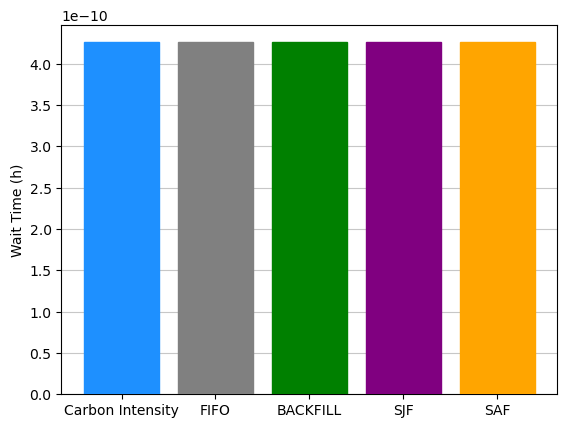

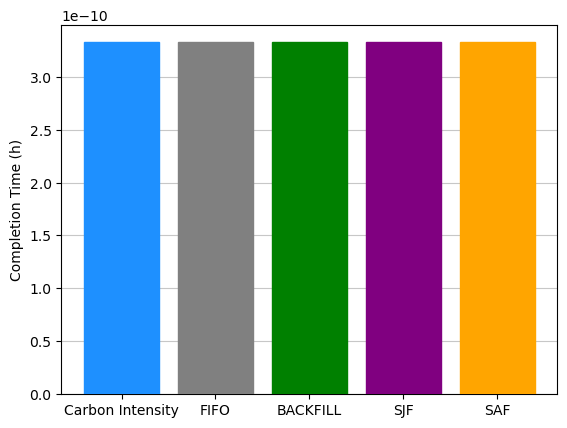

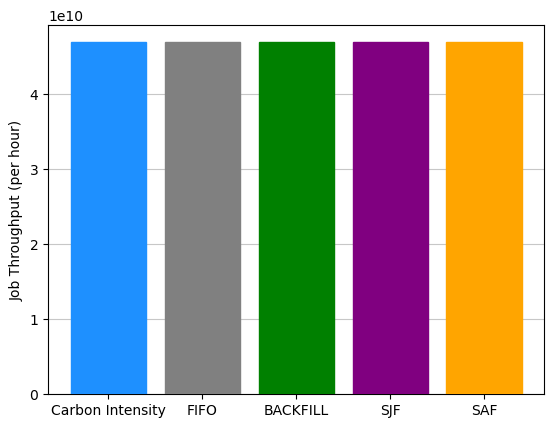

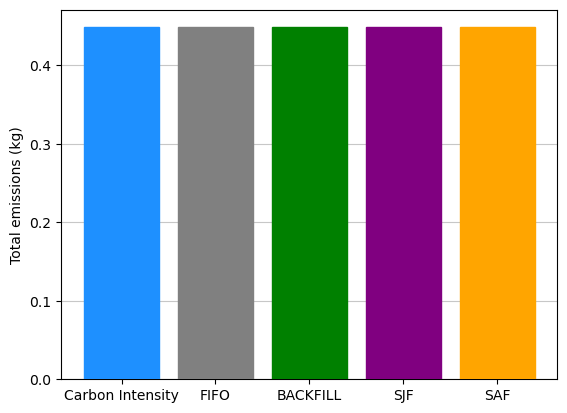

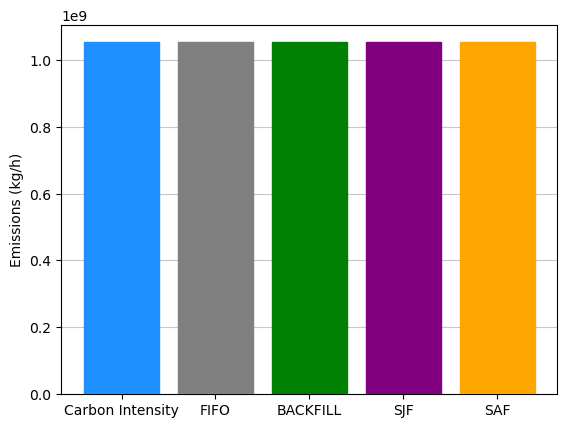

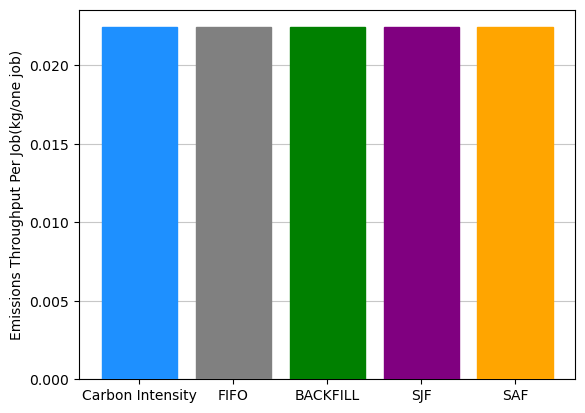

In [75]:
index = ['Carbon Intensity', 'FIFO', 'BACKFILL', 'SJF','SAF']
colors = ['dodgerblue','gray','green','purple','orange']
results = {'ci': ci_result,'fifo':fifo_result,'backfill':backfill_result,'sjf':sjf_result,'saf':saf_result}

def draw_chart(index, colors, value_name, y_label_title,results):
    values = []
    for key in ['ci', 'fifo', 'backfill', 'sjf', 'saf']:
        try:
            values.append(results[key][value_name])
        except (KeyError, TypeError):
            values.append(0)  
            print(f"error: {key} or {value_name} dosen't exist")
    bars = plt.bar(index,values,zorder=3)
    plt.ylabel(y_label_title)
    for i in range(len(index)):
        bars[i].set_color(colors[i])
    
    
    plt.grid(axis='y', alpha=0.7, zorder=0)
    plt.show()
    
#waiting time comparison
draw_chart(index,colors, 'total_completion_time_sum', 'Wait Time (h)', results)
#completion time comparison
draw_chart(index,colors, 'total_waiting_time_sum', 'Completion Time (h)', results)
#job throughput comparison
draw_chart(index,colors, 'job_throughput_per_h', 'Job Throughput (per hour)', results)
#total emissions comparison
draw_chart(index,colors, 'total_emissions_sum', 'Total emissions (kg)', results)
#emissions_rate_kg_per_h comparison
draw_chart(index,colors, 'emissions_rate_kg_per_h', 'Emissions (kg/h)', results)
#emissions_rate_per_job emissions throughput comparison
draw_chart(index,colors, 'emissions_rate_per_job', 'Emissions Throughput Per Job(kg/one job)', results)




